# 0. импорты

In [1]:
# универсальный импорт
# ==================== БАЗОВЫЕ БИБЛИОТЕКИ ====================
import warnings                           # Отключает предупреждения Python
warnings.filterwarnings('ignore')         # Игнорирует все предупреждения (чтобы не мешали)

import numpy as np                        # Работа с массивами и математическими операциями
import pandas as pd                       # Работа с таблицами (DataFrame)

# ==================== ВИЗУАЛИЗАЦИЯ ====================
import matplotlib.pyplot as plt           # Основная библиотека для построения графиков
import seaborn as sns                     # Более красивая и удобная визуализация (на базе matplotlib)
sns.set_style("whitegrid")                # Устанавливает стиль графиков (белая сетка)
plt.rcParams['figure.figsize'] = (10, 6)  # Размер графиков по умолчанию

# ==================== SCIKIT-LEARN: РАЗБИЕНИЕ И ОПТИМИЗАЦИЯ ====================
from sklearn.model_selection import train_test_split          # Разбиение данных на train и test
from sklearn.model_selection import StratifiedKFold           # Разбиение с сохранением баланса классов
from sklearn.model_selection import GridSearchCV              # Поиск лучших гиперпараметров (полный перебор)
from sklearn.model_selection import learning_curve            # Построение кривой обучения
from sklearn.model_selection import validation_curve          # Построение кривой валидации

# ==================== SCIKIT-LEARN: ПРЕДОБРАБОТКА ====================
from sklearn.compose import ColumnTransformer                 # Объединяет разные преобразования для колонок
from sklearn.pipeline import Pipeline                         # Объединяет шаги предобработки и модель в один объект
from sklearn.preprocessing import StandardScaler              # Стандартизация (среднее = 0, std = 1)
from sklearn.preprocessing import OneHotEncoder               # Кодирование категориальных признаков (One-Hot)
from sklearn.preprocessing import LabelEncoder                # Кодирование целевой переменной (в числа)
from sklearn.impute import SimpleImputer                      # Заполнение пропущенных значений

# ==================== SCIKIT-LEARN: МОДЕЛИ ====================
from sklearn.linear_model import LogisticRegression           # Логистическая регрессия (простая модель)
from sklearn.ensemble import RandomForestClassifier           # Случайный лес (мощная модель)
from sklearn.neural_network import MLPClassifier              # Глубокое обучение

# ==================== SCIKIT-LEARN: МЕТРИКИ ====================
from sklearn.metrics import accuracy_score                    # Доля правильных ответов
from sklearn.metrics import f1_score                          # F1-мера (хорошо работает при дисбалансе)
from sklearn.metrics import roc_auc_score                     # Площадь под ROC-кривой
from sklearn.metrics import classification_report             # Полный отчёт по метрикам
from sklearn.metrics import confusion_matrix                  # Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay            # Красивое отображение матрицы ошибок

# ==================== СОХРАНЕНИЕ ====================
import joblib                                                 # Сохранение и загрузка моделей

## 1. Загрузка данных и первичный осмотр структуры

На этом этапе важно не просто вывести `head()`, а описать размер таблицы, типы данных, целевую переменную, пропуски, дубликаты и потенциально проблемные признаки.

In [2]:
DATA_PATH = 'wine_exam_example_dirty.csv'

df = pd.read_csv(DATA_PATH)

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (183, 17)


,SampleID,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WineClass,TargetCodeLeak,AlcoholLevel
0,1020,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,A,0,high
1,1043,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,A,0,high
2,1156,13.17,5.19,2.32,22.0,93.0,1.74,0.63,0.61,1.55,7.90,0.60,1.48,NaN,C,2,medium
3,1112,12.52,2.43,2.17,21.0,88.0,2.55,2.27,0.26,1.22,2.00,0.90,2.78,325.0,B,1,medium
4,1148,12.87,4.61,2.48,21.5,86.0,1.70,0.65,0.47,0.86,7.65,0.54,1.86,625.0,C,2,medium


In [3]:
print('Информация о датасете:')
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SampleID                      183 non-null    int64  
 1   alcohol                       175 non-null    float64
 2   malic_acid                    183 non-null    float64
 3   ash                           183 non-null    float64
 4   alcalinity_of_ash             183 non-null    float64
 5   magnesium                     183 non-null    float64
 6   total_phenols                 183 non-null    float64
 7   flavanoids                    183 non-null    float64
 8   nonflavanoid_phenols          183 non-null    float64
 9   proanthocyanins               183 non-null    float64
 10  color_intensity               176 non-null    float64
 11  hue                           183 non-null    float64
 12  od280/od315_of_diluted_wines  183 non-nul

In [4]:
print('Количество пропусков по столбцам:')
df.isna().sum().sort_values(ascending=False)

Количество пропусков по столбцам:


proline                         10
alcohol                          8
color_intensity                  7
SampleID                         0
malic_acid                       0
magnesium                        0
total_phenols                    0
ash                              0
alcalinity_of_ash                0
nonflavanoid_phenols             0
flavanoids                       0
hue                              0
proanthocyanins                  0
od280/od315_of_diluted_wines     0
WineClass                        0
TargetCodeLeak                   0
AlcoholLevel                     0
dtype: int64

## 2. Предобработка данных

В этом разделе выполняется очистка данных:

- удаление дубликатов;
- обработка грязных категориальных значений;
- удаление признаков, которые нельзя использовать для обучения;
- проверка пропусков;
- подготовка целевой переменной.

Важно: числовые пропуски и категориальные пропуски далее будут обработаны внутри Pipeline, чтобы не было утечки данных из валидационной выборки.

In [5]:
# универсальный блок
'''
# ==================== ПРЕДОБРАБОТКА ДАННЫХ ====================
clean_df = df.copy()

# --- 1. Удаление дубликатов ---
print('Дубликаты до очистки:', clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()
print('Строк после удаления дубликатов:', clean_df.shape[0])

# --- 2. Удаление ненужных признаков ---
# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: добавь сюда колонки, которые нужно удалить
cols_to_drop = ['SampleID', 'TargetCodeLeak']

existing_cols_to_drop = [col for col in cols_to_drop if col in clean_df.columns]
clean_df = clean_df.drop(columns=existing_cols_to_drop)
print('Удалённые признаки:', existing_cols_to_drop)

# --- 3. Очистка грязных категориальных значений ---
# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: укажи колонку и допустимые значения
dirty_cat_col = 'AlcoholLevel'
allowed_values = ['low', 'medium', 'high']

if dirty_cat_col in clean_df.columns:
    clean_df[dirty_cat_col] = clean_df[dirty_cat_col].where(
        clean_df[dirty_cat_col].isin(allowed_values), np.nan
    )
    print(f'Уникальные значения {dirty_cat_col} после очистки:')
    print(clean_df[dirty_cat_col].unique())

# --- 4. Проверка целевой переменной ---
target_col = 'WineClass'  # <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ (название целевой)
print('\nРаспределение целевой переменной:')
print(clean_df[target_col].value_counts())
'''

"\n# ==================== ПРЕДОБРАБОТКА ДАННЫХ ====================\nclean_df = df.copy()\n\n# --- 1. Удаление дубликатов ---\nprint('Дубликаты до очистки:', clean_df.duplicated().sum())\nclean_df = clean_df.drop_duplicates()\nprint('Строк после удаления дубликатов:', clean_df.shape[0])\n\n# --- 2. Удаление ненужных признаков ---\n# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: добавь сюда колонки, которые нужно удалить\ncols_to_drop = ['SampleID', 'TargetCodeLeak']\n\nexisting_cols_to_drop = [col for col in cols_to_drop if col in clean_df.columns]\nclean_df = clean_df.drop(columns=existing_cols_to_drop)\nprint('Удалённые признаки:', existing_cols_to_drop)\n\n# --- 3. Очистка грязных категориальных значений ---\n# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: укажи колонку и допустимые значения\ndirty_cat_col = 'AlcoholLevel'\nallowed_values = ['low', 'medium', 'high']\n\nif dirty_cat_col in clean_df.columns:\n    clean_df[dirty_cat_col] = clean_df[dirty_cat_col].where(\n        clean_df[dirty_cat_col].isin(allowed_values), 

In [6]:
clean_df = df.copy()

In [7]:
# --- 1. Удаление дубликатов ---
print('Дубликаты до очистки:', clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()
print('Строк после удаления дубликатов:', clean_df.shape[0])

Дубликаты до очистки: 5
Строк после удаления дубликатов: 178


In [8]:
# --- 2. Удаление ненужных признаков ---
# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: добавь сюда колонки, которые нужно удалить
cols_to_drop = ['SampleID', 'TargetCodeLeak']

existing_cols_to_drop = [col for col in cols_to_drop if col in clean_df.columns]
clean_df = clean_df.drop(columns=existing_cols_to_drop)
print('Удалённые признаки:', existing_cols_to_drop)

Удалённые признаки: ['SampleID', 'TargetCodeLeak']


In [9]:
# --- 3. Очистка грязных категориальных значений ---
# Посмотрим уникальные значения категориальных признаков
cat_cols_initial = df.select_dtypes(include='object').columns

for col in cat_cols_initial:
    print(f'{col}:', df[col].unique())
    
# <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ: укажи колонку и допустимые значения
dirty_cat_col = 'AlcoholLevel'
allowed_values = ['low', 'medium', 'high']

if dirty_cat_col in clean_df.columns:
    clean_df[dirty_cat_col] = clean_df[dirty_cat_col].where(
        clean_df[dirty_cat_col].isin(allowed_values), np.nan
    )
    print(f'Уникальные значения {dirty_cat_col} после очистки:')
    print(clean_df[dirty_cat_col].unique())

WineClass: ['A' 'C' 'B']
AlcoholLevel: ['high' 'medium' '42' 'low' '777' '999']
Уникальные значения AlcoholLevel после очистки:
['high' 'medium' nan 'low']


In [10]:
# --- 4. Проверка целевой переменной ---
target_col = 'WineClass'  # <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ (название целевой)
print('\nРаспределение целевой переменной:')
print(clean_df[target_col].value_counts())


Распределение целевой переменной:
WineClass
B    71
A    59
C    48
Name: count, dtype: int64


## 3. Анализ EDA

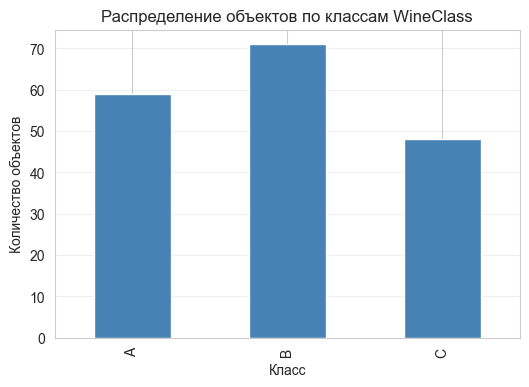

In [11]:
# ==================== EDA: Распределение целевой переменной ====================
target_col = 'WineClass'                    # <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ

plt.figure(figsize=(6, 4))
clean_df[target_col].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title(f'Распределение объектов по классам {target_col}')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
# Описательная статистика числовых признаков
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,170.0,13.005176,0.817320,11.03,12.3450,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,171.0,5.066608,2.343109,1.28,3.2300,4.680,6.2250,13.00


In [13]:
# 1шаг-глянуть как отображается в общем виде boxplot
'''
# Boxplot числовых признаков для поиска потенциальных выбросов
numeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 6))
clean_df[numeric_cols].boxplot(rot=45)
plt.title('Boxplot числовых признаков')
plt.ylabel('Значения признаков')
plt.grid(True)
plt.show()
'''

"\n# Boxplot числовых признаков для поиска потенциальных выбросов\nnumeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()\n\nplt.figure(figsize=(14, 6))\nclean_df[numeric_cols].boxplot(rot=45)\nplt.title('Boxplot числовых признаков')\nplt.ylabel('Значения признаков')\nplt.grid(True)\nplt.show()\n"

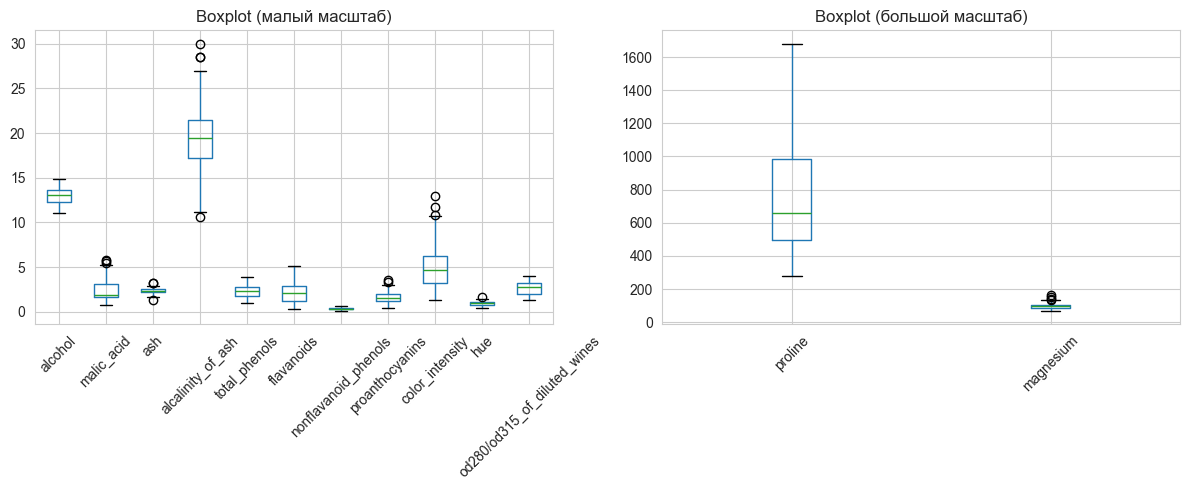

In [14]:
# 2шаг-при необходимости отразить в разных масштабах
numeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()

# Разделяем на признаки с большим и маленьким масштабом
large_scale = ['proline', 'magnesium']           # <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ
small_scale = [col for col in numeric_cols if col not in large_scale]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
clean_df[small_scale].boxplot(rot=45)
plt.title('Boxplot (малый масштаб)')
plt.grid(True)

plt.subplot(1, 2, 2)
clean_df[large_scale].boxplot(rot=45)
plt.title('Boxplot (большой масштаб)')
plt.grid(True)

plt.tight_layout()
plt.show()

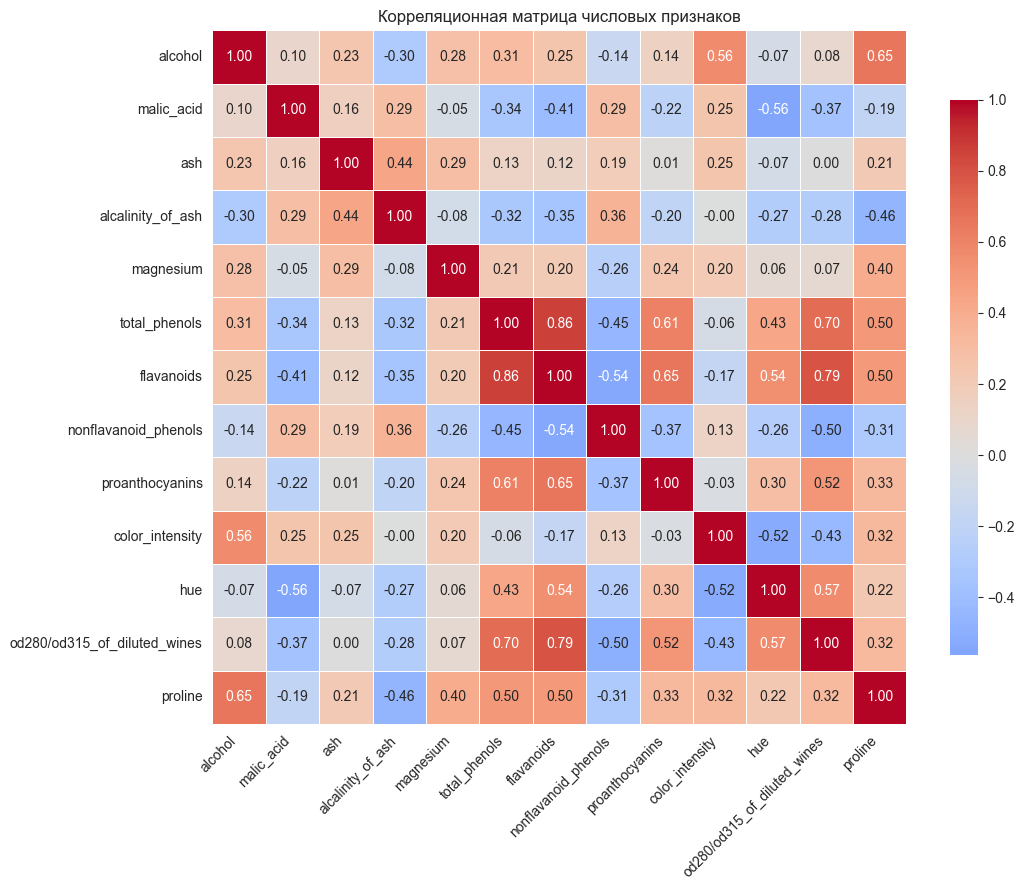

In [15]:
# Корреляционная матрица числовых признаков
# версия АС
'''
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()
'''
# новая универсальная
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица числовых признаков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

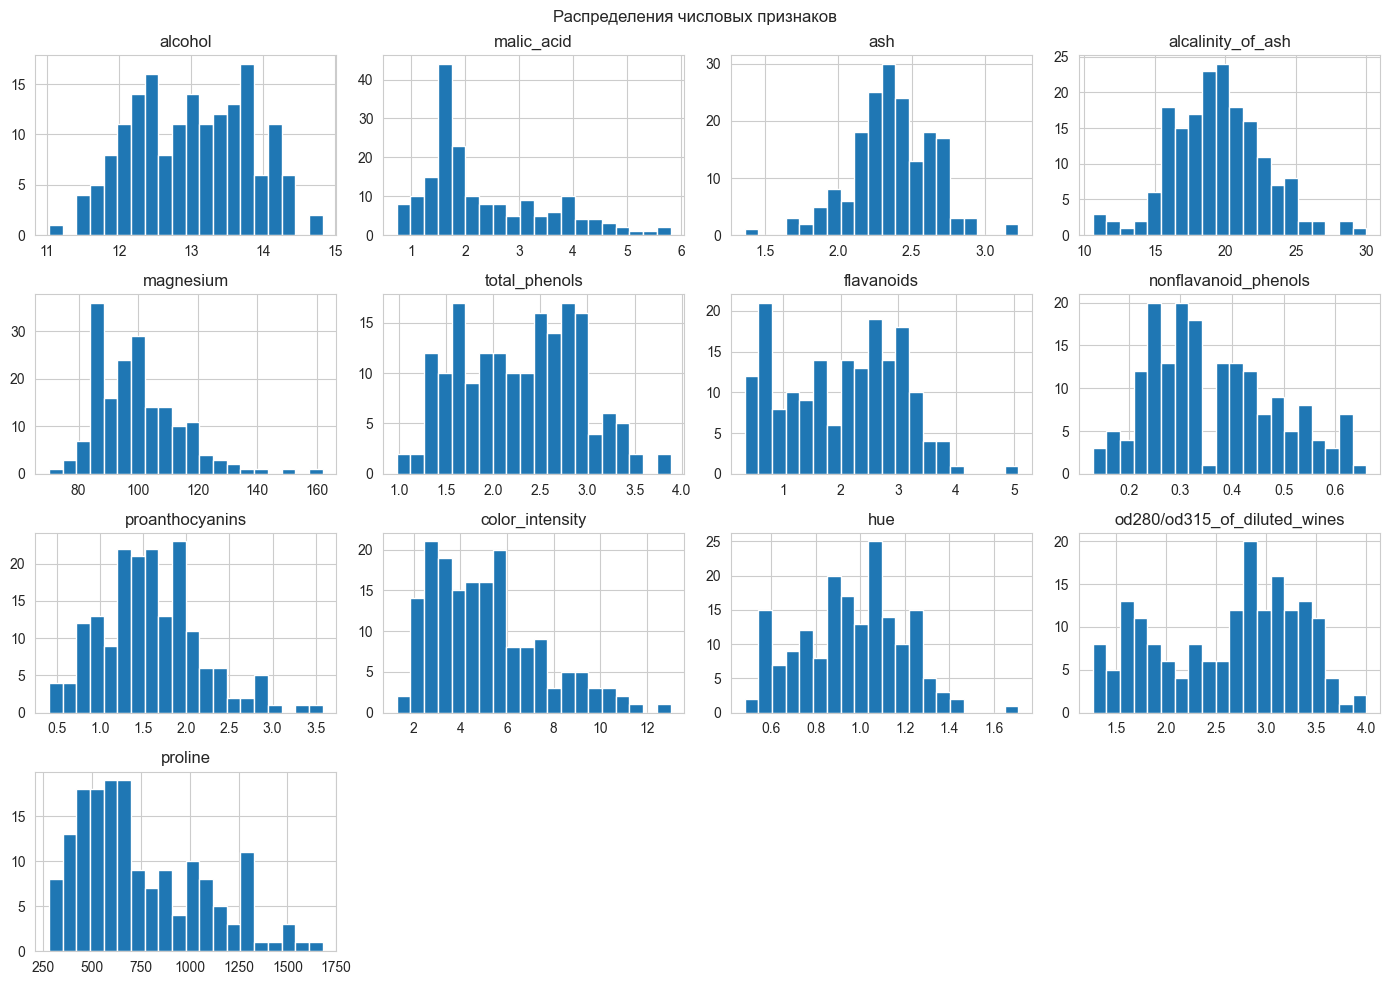

In [16]:
# Гистограммы числовых признаков
clean_df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Распределения числовых признаков')
plt.tight_layout()
plt.show()

## 4. Набор данных

In [17]:
# ==================== ФОРМИРОВАНИЕ X и y ====================
TARGET = 'WineClass'                                    # <-- ИЗМЕНИТЬ ПОД ДАТАСЕТ

X = clean_df.drop(columns=[TARGET])
y = clean_df[TARGET]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Классы:', list(label_encoder.classes_))
print('Размер X:', X.shape)
print('Размер y:', y_encoded.shape)
# ==================== РАЗБИЕНИЕ ДАННЫХ ====================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_encoded,
    test_size=0.25,                                     # <-- ИЗМЕНИТЬ (рекомендуется 0.2–0.3)
    random_state=42,
    stratify=y_encoded
)

print('Размер обучающей выборки:', X_train.shape)
print('Размер валидационной выборки:', X_valid.shape)
# ==================== ПРЕДОБРАБОТКА ====================
# Универсальная предобработка:
# - для числовых признаков: заполнение пропусков медианой + стандартизация;
# - для категориальных признаков: заполнение самым частым значением + one-hot encoding.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Классы: ['A', 'B', 'C']
Размер X: (178, 14)
Размер y: (178,)
Размер обучающей выборки: (133, 14)
Размер валидационной выборки: (45, 14)
Числовые признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Категориальные признаки: ['AlcoholLevel']


## 5. Логистическая регрессия

In [18]:
# ==================== ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ====================
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=5000,
        random_state=42,
        class_weight='balanced'                    # Учитываем дисбаланс
    ))
])

log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_valid)

print('=== Logistic Regression ===')
print('Accuracy:', accuracy_score(y_valid, y_pred_lr))
print('F1-score (weighted):', f1_score(y_valid, y_pred_lr, average='weighted'))
print(classification_report(y_valid, y_pred_lr, target_names=label_encoder.classes_))

=== Logistic Regression ===
Accuracy: 0.9333333333333333
F1-score (weighted): 0.9321363636363637
              precision    recall  f1-score   support

           A       0.88      1.00      0.94        15
           B       1.00      0.83      0.91        18
           C       0.92      1.00      0.96        12

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.94      0.93      0.93        45



## 6. Оптимизация логистической регерессии

Оптимизируем логистическую регрессию с помощью GridSearchCV.
Подбираем:

C — силу регуляризации;
penalty — тип регуляризации;
solver — алгоритм оптимизации.
Маленькое C означает сильную регуляризацию, большое C — слабую регуляризацию.

In [19]:
param_grid_lr = [
    {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },
    {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs']
    }
]

grid_lr = GridSearchCV(
    estimator=log_reg_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1_weighted',           # Лучше accuracy при дисбалансе
    n_jobs=-1,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)

print("Лучшие параметры:", grid_lr.best_params_)
print("Лучший F1-score на CV:", round(grid_lr.best_score_, 4))

y_pred_opt = grid_lr.predict(X_valid)
print("\n=== Результаты на валидации ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_opt))
print("F1-score (weighted):", f1_score(y_valid, y_pred_opt, average='weighted'))
print(classification_report(y_valid, y_pred_opt, target_names=label_encoder.classes_))

Лучшие параметры: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Лучший F1-score на CV: 0.9779

=== Результаты на валидации ===
Accuracy: 0.9111111111111111
F1-score (weighted): 0.9096176821983273
              precision    recall  f1-score   support

           A       0.94      1.00      0.97        15
           B       1.00      0.78      0.88        18
           C       0.80      1.00      0.89        12

    accuracy                           0.91        45
   macro avg       0.91      0.93      0.91        45
weighted avg       0.93      0.91      0.91        45



## 7. Графики логистической регерссии

Для логистической регрессии строим:

матрицу ошибок;
кривую валидации по параметру C;
кривую обучения.

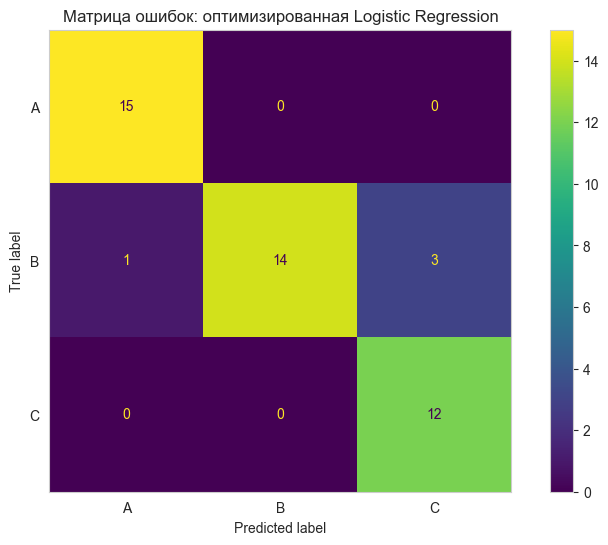

In [21]:
cm_lr = confusion_matrix(y_valid, y_pred_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.grid(False)
plt.title('Матрица ошибок: оптимизированная Logistic Regression')
plt.show()

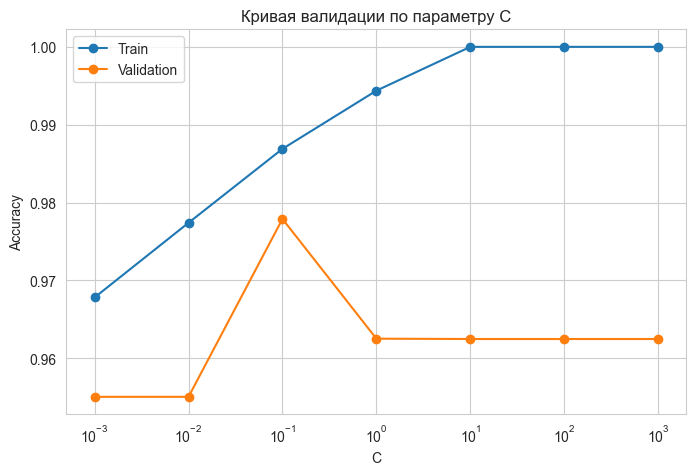

In [22]:
# ==================== КРИВАЯ ВАЛИДАЦИИ ====================
param_range_C = np.logspace(-3, 3, 7)

# Создаём базовую модель (удобнее для запоминания)
base_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000, solver='liblinear', penalty='l2', random_state=42))
])

train_scores, valid_scores = validation_curve(
    estimator=base_model,
    X=X_train,
    y=y_train,
    param_name='model__C',
    param_range=param_range_C,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range_C, train_mean, marker='o', label='Train')
plt.semilogx(param_range_C, valid_mean, marker='o', label='Validation')
plt.title('Кривая валидации по параметру C')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

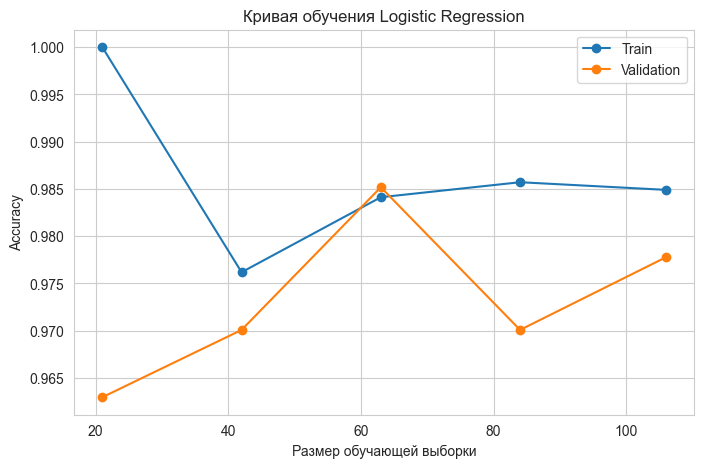

In [23]:
train_sizes_lr, train_scores_lc_lr, valid_scores_lc_lr = learning_curve(
    estimator=grid_lr.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_lr, train_scores_lc_lr.mean(axis=1), marker='o', label='Train')
plt.plot(train_sizes_lr, valid_scores_lc_lr.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая обучения Logistic Regression')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 8. Random Forest

In [24]:
# ==================== RANDOM FOREST ====================
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_valid)

print('=== Random Forest ===')
print('Accuracy:', round(accuracy_score(y_valid, y_pred_rf), 4))
print('F1-score (weighted):', round(f1_score(y_valid, y_pred_rf, average='weighted'), 4))
print(classification_report(y_valid, y_pred_rf, target_names=label_encoder.classes_))

=== Random Forest ===
Accuracy: 0.9556
F1-score (weighted): 0.9551
              precision    recall  f1-score   support

           A       0.94      1.00      0.97        15
           B       1.00      0.89      0.94        18
           C       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



## 9. Оптимизация random forest

In [25]:
# ==================== ОПТИМИЗАЦИЯ RANDOM FOREST ====================
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Лучшие параметры Random Forest:")
print(grid_rf.best_params_)
print("\nЛучший F1-score на кросс-валидации:", round(grid_rf.best_score_, 4))

y_pred_rf_opt = grid_rf.predict(X_valid)

print("\n=== Результаты оптимизированной модели на валидации ===")
print("Accuracy:", round(accuracy_score(y_valid, y_pred_rf_opt), 4))
print("F1-score (weighted):", round(f1_score(y_valid, y_pred_rf_opt, average='weighted'), 4))
print(classification_report(y_valid, y_pred_rf_opt, target_names=label_encoder.classes_))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры Random Forest:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Лучший F1-score на кросс-валидации: 0.9926

=== Результаты оптимизированной модели на валидации ===
Accuracy: 0.9333
F1-score (weighted): 0.9328
              precision    recall  f1-score   support

           A       0.93      0.93      0.93        15
           B       0.94      0.89      0.91        18
           C       0.92      1.00      0.96        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45



## 10. Графики для random forest

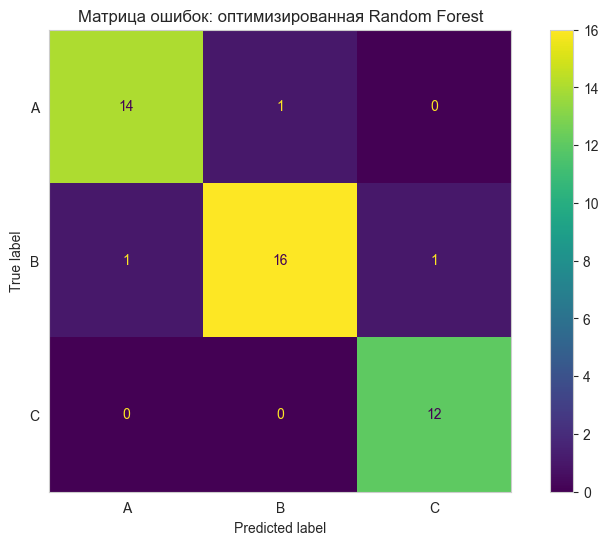

In [26]:
# ==================== МАТРИЦА ОШИБОК RANDOM FOREST ====================
cm_rf = confusion_matrix(y_valid, y_pred_rf_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.grid(False)
plt.title('Матрица ошибок: оптимизированная Random Forest')
plt.show()

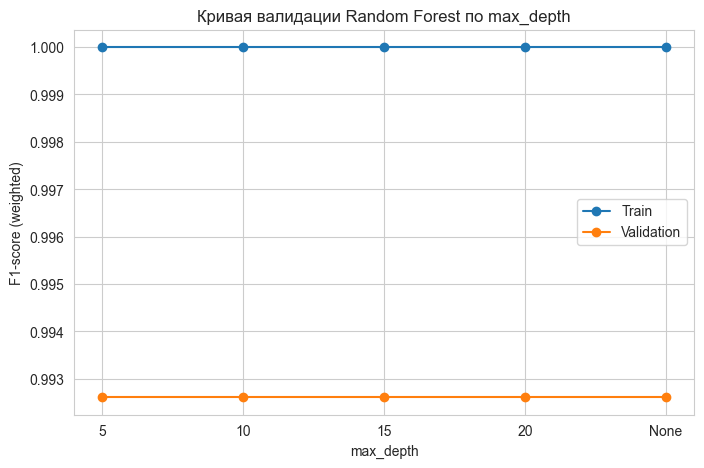

In [27]:
param_range = [5, 10, 15, 20, None]

train_scores, valid_scores = validation_curve(
    estimator=grid_rf.best_estimator_,
    X=X_train,
    y=y_train,
    param_name='model__max_depth',
    param_range=param_range,
    cv=5,
    scoring='f1_weighted',           # ← лучше accuracy
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot([str(x) for x in param_range], train_scores.mean(axis=1), marker='o', label='Train')
plt.plot([str(x) for x in param_range], valid_scores.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая валидации Random Forest по max_depth')
plt.xlabel('max_depth')
plt.ylabel('F1-score (weighted)')
plt.legend()
plt.grid(True)
plt.show()

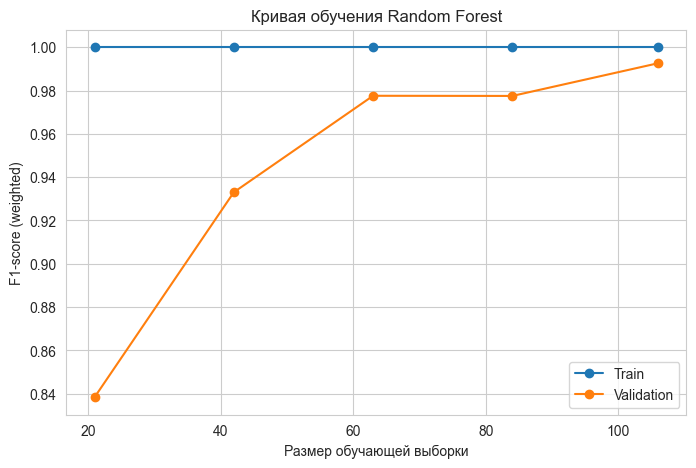

In [28]:
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=grid_rf.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1_weighted',           # ← лучше accuracy
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
plt.plot(train_sizes, valid_scores.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая обучения Random Forest')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('F1-score (weighted)')
plt.legend()
plt.grid(True)
plt.show()

## 11. Глубокое обучение

In [29]:
mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_valid)

print('Accuracy MLP:', accuracy_score(y_valid, y_pred_mlp))
print(classification_report(y_valid, y_pred_mlp, target_names=label_encoder.classes_))

Accuracy MLP: 0.6666666666666666
              precision    recall  f1-score   support

           A       0.62      1.00      0.77        15
           B       1.00      0.17      0.29        18
           C       0.67      1.00      0.80        12

    accuracy                           0.67        45
   macro avg       0.76      0.72      0.62        45
weighted avg       0.79      0.67      0.58        45



## 12. Оптимизация глубокого обучения

In [30]:
# ==================== ОПТИМИЗАЦИЯ MLPCLASSIFIER ====================
param_grid_mlp = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__learning_rate_init': [0.001, 0.005]
}

grid_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='f1_weighted',           # Лучше accuracy при дисбалансе
    n_jobs=-1,
    verbose=1
)

grid_mlp.fit(X_train, y_train)

print('Лучшие параметры MLP:')
print(grid_mlp.best_params_)
print('Лучший F1-score на кросс-валидации:', round(grid_mlp.best_score_, 4))

y_pred_mlp_opt = grid_mlp.predict(X_valid)

print('\n=== Результаты оптимизированной MLP на валидации ===')
print('Accuracy:', round(accuracy_score(y_valid, y_pred_mlp_opt), 4))
print('F1-score (weighted):', round(f1_score(y_valid, y_pred_mlp_opt, average='weighted'), 4))
print(classification_report(y_valid, y_pred_mlp_opt, target_names=label_encoder.classes_))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры MLP:
{'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.005}
Лучший F1-score на кросс-валидации: 0.955

=== Результаты оптимизированной MLP на валидации ===
Accuracy: 0.8889
F1-score (weighted): 0.8881
              precision    recall  f1-score   support

           A       0.88      0.93      0.90        15
           B       1.00      0.78      0.88        18
           C       0.80      1.00      0.89        12

    accuracy                           0.89        45
   macro avg       0.89      0.90      0.89        45
weighted avg       0.91      0.89      0.89        45



## 13. Графики глубокой модели

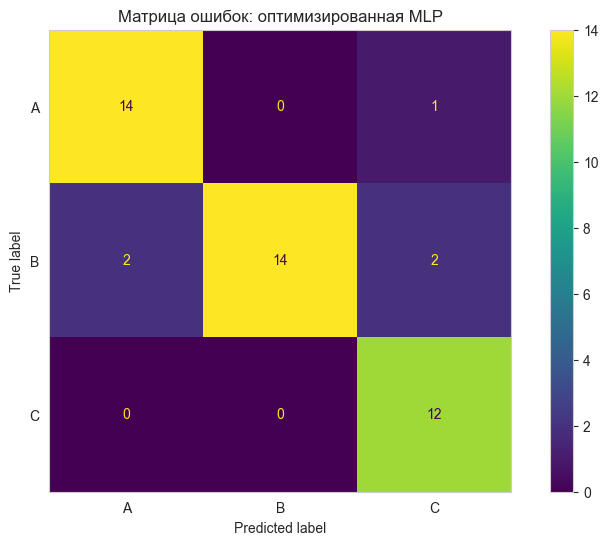

In [32]:
cm_mlp = confusion_matrix(y_valid, y_pred_mlp_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.grid(False)
plt.title('Матрица ошибок: оптимизированная MLP')
plt.show()

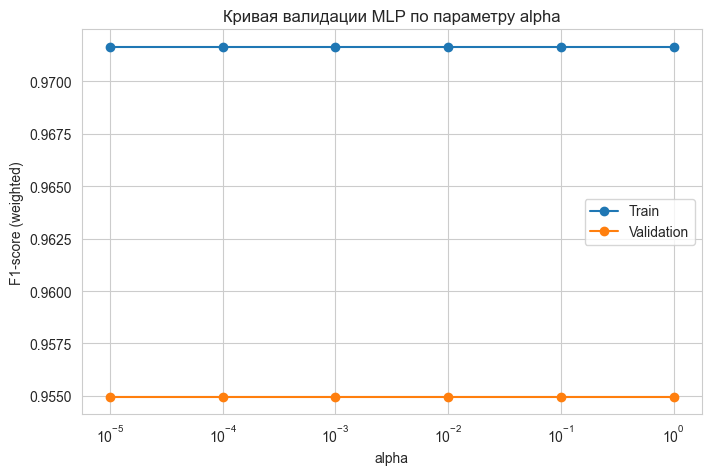

In [33]:
# ==================== КРИВАЯ ВАЛИДАЦИИ MLP (оптимизированная модель) ====================
param_range_alpha = np.logspace(-5, 0, 6)

train_scores_mlp, valid_scores_mlp = validation_curve(
    estimator=grid_mlp.best_estimator_,           # ← используем оптимизированную модель
    X=X_train,
    y=y_train,
    param_name='model__alpha',
    param_range=param_range_alpha,
    cv=5,
    scoring='f1_weighted',                        # лучше accuracy
    n_jobs=-1
)

train_mean_mlp = train_scores_mlp.mean(axis=1)
valid_mean_mlp = valid_scores_mlp.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range_alpha, train_mean_mlp, marker='o', label='Train')
plt.semilogx(param_range_alpha, valid_mean_mlp, marker='o', label='Validation')
plt.title('Кривая валидации MLP по параметру alpha')
plt.xlabel('alpha')
plt.ylabel('F1-score (weighted)')
plt.legend()
plt.grid(True)
plt.show()

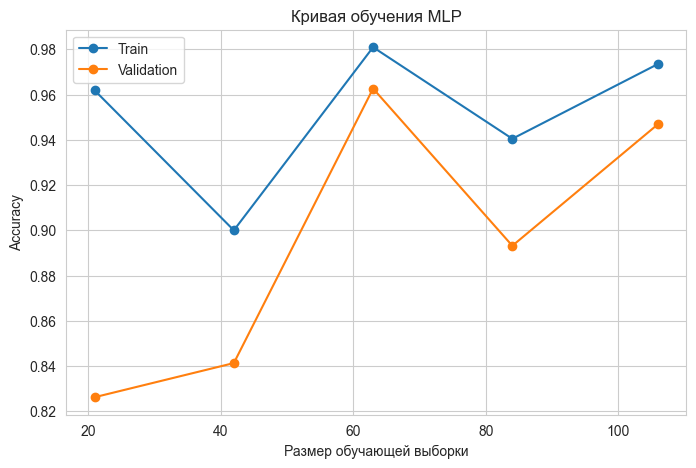

In [34]:
train_sizes_mlp, train_scores_lc_mlp, valid_scores_lc_mlp = learning_curve(
    estimator=grid_mlp.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_mlp, train_scores_lc_mlp.mean(axis=1), marker='o', label='Train')
plt.plot(train_sizes_mlp, valid_scores_lc_mlp.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая обучения MLP')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

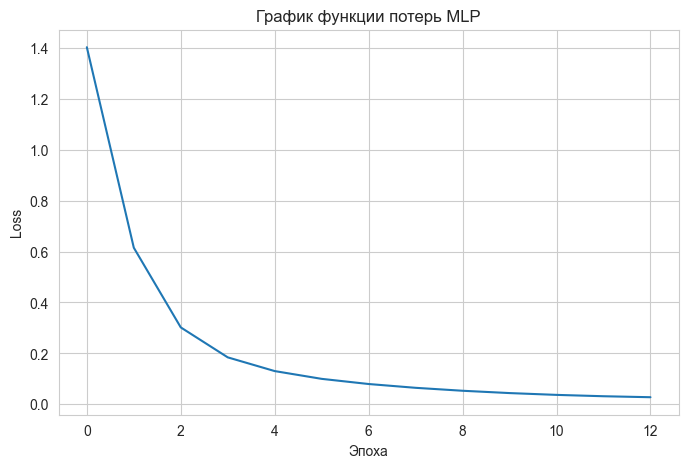

In [35]:
# График функции потерь лучшей нейронной сети
best_mlp = grid_mlp.best_estimator_.named_steps['model']

plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.title('График функции потерь MLP')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## 14. Сравнение качества и сохранение лучшей модели

                            Модель  Accuracy
0       Logistic Regression (base)  0.933333
1  Logistic Regression (optimized)  0.911111
2             Random Forest (base)  0.955556
3        Random Forest (optimized)  0.933333
4             MLPClassifier (base)  0.666667
5        MLPClassifier (optimized)  0.888889


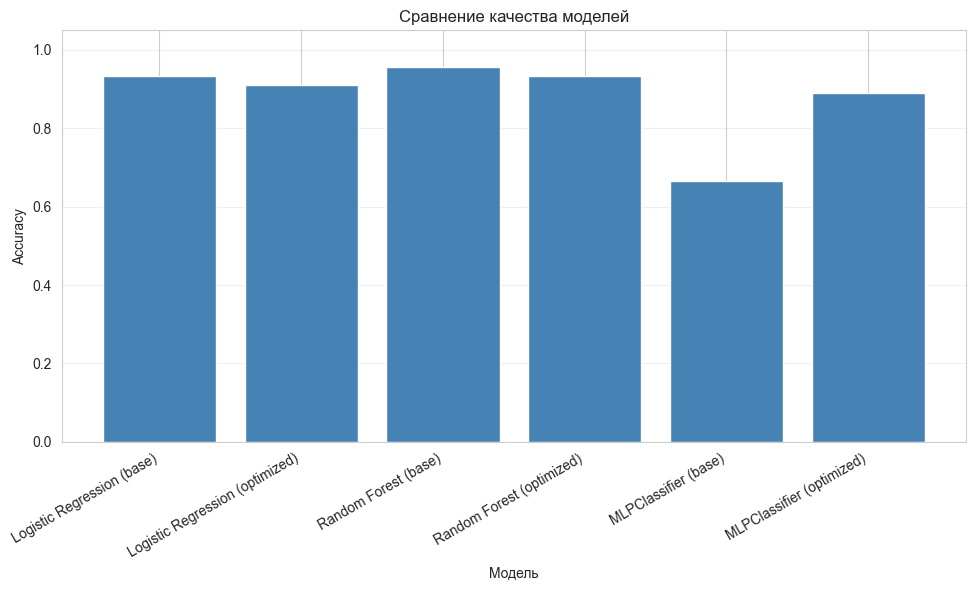

In [37]:
# ==================== СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ====================
results = pd.DataFrame({
    'Модель': [
        'Logistic Regression (base)',
        'Logistic Regression (optimized)',
        'Random Forest (base)',
        'Random Forest (optimized)',
        'MLPClassifier (base)',
        'MLPClassifier (optimized)'
    ],
    'Accuracy': [
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_opt),
        accuracy_score(y_valid, y_pred_rf),           # <-- добавь эту переменную, если ещё нет
        accuracy_score(y_valid, y_pred_rf_opt),
        accuracy_score(y_valid, y_pred_mlp),
        accuracy_score(y_valid, y_pred_mlp_opt)
    ]
})

print(results)

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(results['Модель'], results['Accuracy'], color=['steelblue']*6)
plt.title('Сравнение качества моделей')
plt.xlabel('Модель')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# ==================== ОПРЕДЕЛЕНИЕ ЛУЧШЕЙ МОДЕЛИ ====================
# Считаем accuracy для всех моделей
acc_lr      = accuracy_score(y_valid, y_pred_lr)
acc_lr_opt  = accuracy_score(y_valid, y_pred_opt)
acc_rf      = accuracy_score(y_valid, y_pred_rf)
acc_rf_opt  = accuracy_score(y_valid, y_pred_rf_opt)
acc_mlp     = accuracy_score(y_valid, y_pred_mlp)
acc_mlp_opt = accuracy_score(y_valid, y_pred_mlp_opt)

# Создаём словарь с моделями и их accuracy
models_dict = {
    'Logistic Regression (base)':       (acc_lr,      None),
    'Logistic Regression (optimized)':  (acc_lr_opt,  grid_lr.best_estimator_),
    'Random Forest (base)':             (acc_rf,      rf_model),
    'Random Forest (optimized)':        (acc_rf_opt,  grid_rf.best_estimator_),
    'MLPClassifier (base)':             (acc_mlp,     mlp_model),
    'MLPClassifier (optimized)':        (acc_mlp_opt, grid_mlp.best_estimator_)
}

# Находим модель с максимальной accuracy
best_model_name = max(models_dict, key=lambda x: models_dict[x][0])
best_accuracy   = models_dict[best_model_name][0]
best_model      = models_dict[best_model_name][1]

print(f'Лучшая модель: {best_model_name}')
print(f'Accuracy лучшей модели: {best_accuracy:.4f}')

# ==================== СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ ====================
joblib.dump(best_model, 'best_exam_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print('\nМодель сохранена в файл: best_exam_model.pkl')
print('Кодировщик целевой переменной сохранён в файл: label_encoder.pkl')

Лучшая модель: Random Forest (base)
Accuracy лучшей модели: 0.9556

Модель сохранена в файл: best_exam_model.pkl
Кодировщик целевой переменной сохранён в файл: label_encoder.pkl


In [40]:
# ==================== ПРОВЕРКА ЗАГРУЗКИ МОДЕЛИ ====================
loaded_model = joblib.load('best_exam_model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

sample_prediction = loaded_model.predict(X_valid.head(5))
print('Предсказания для первых 5 объектов:', loaded_encoder.inverse_transform(sample_prediction))

Предсказания для первых 5 объектов: ['A' 'C' 'A' 'A' 'B']
